In [1]:
import os
import sys
import numpy as np
sys.path.append('/app/src')
from data_loader import DataLoader
from noise_optimizers import EKF_NoiseOptimizer

%matplotlib inline
np.random.seed(777)

## Load data

In [2]:
root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
noise_optimizer_dir = os.path.join(root_path, "exports/_noise_optimizations")
noise_vector_dir = os.path.join(noise_optimizer_dir, "noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                kitti_root_dir=kitti_root_dir, 
                noise_vector_dir=noise_vector_dir,
                vo_dropout_ratio=0.0, 
                gps_dropout_ratio=0.0,
                visualize_data=False)

Data sampling is set to normal mode.


In [3]:
error_df_export_path = os.path.join(noise_optimizer_dir, "errors/ekf")
noise_vector_export_path = os.path.join(noise_vector_dir, 'ekf')

In [4]:
ekf_optimizer = EKF_NoiseOptimizer(data=data, 
                                   error_df_export_path=error_df_export_path, 
                                   noise_vector_export_path=noise_vector_export_path)

In [5]:
ekf_optimizer.run()

Finding optimal noise vector
For setup 1
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.901
             x: [ 1.000e+00  1.000e+00  1.000e+00  1.000e+00  1.000e+00
                  1.000e+00  1.000e+00  1.000e+00  1.000e+00  1.000e+00]
           nit: 10
          nfev: 119
 final_simplex: (array([[ 1.000e+00,  1.000e+00, ...,  1.000e+00,
                         1.000e+00],
                       [ 1.000e+00,  1.000e+00, ...,  1.000e+00,
                         1.000e+00],
                       ...,
                       [ 1.000e+00,  1.000e+00, ...,  1.000e+00,
                         1.000e+00],
                       [ 1.000e+00,  1.000e+00, ...,  1.000e+00,
                         1.000e+00]]), array([ 3.901e+00,  3.901e+00,  3.901e+00,  3.901e+00,
                        3.901e+00,  3.901e+00,  3.901e+00,  3.901e+00,
                        3.901e+00,  3.901e+00,  3.901e+00]))
For setup 2
       message: Optimi

In [6]:
ekf_optimizer.compare(load_exported=True)

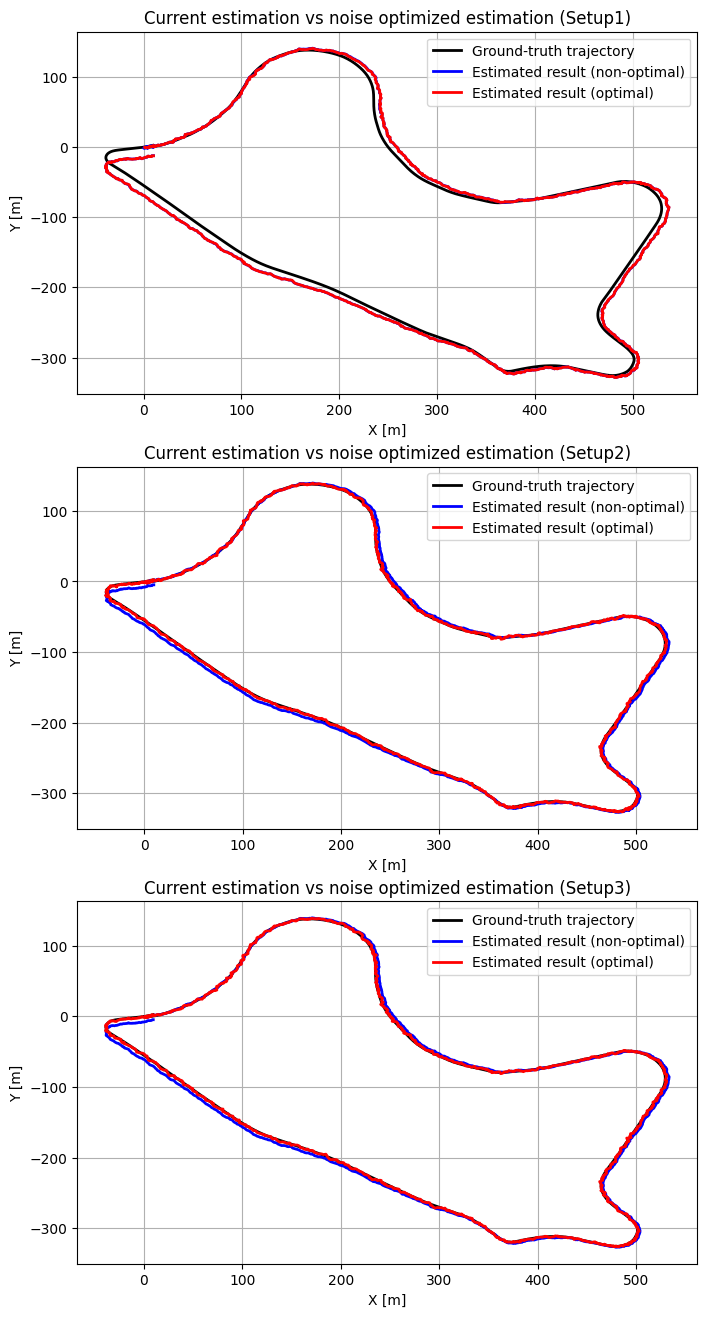

In [7]:
ekf_optimizer.visualize_results()

In [8]:
ekf_optimizer.error_df

Setups        Setup1(IMU+VO)                Setup2(IMU+VO,GPS)                \
Error types              MAE   RMSE     MAX                MAE   RMSE    MAX   
Non-optimized          3.904  5.486  16.056              1.990  2.762  8.483   
Optimized              3.901  5.487  16.329              0.664  0.842  3.395   
∆                     -0.003  0.001   0.273             -1.326 -1.920 -5.088   

Setups        Setup3(INS)                
Error types           MAE   RMSE    MAX  
Non-optimized       1.948  2.737  8.202  
Optimized           0.549  0.704  2.862  
∆                  -1.399 -2.033 -5.340

## Conclusion

The noise optimization is successfully applied to the EKF and the resulted noise vectors, including process noise and measurement noise for both VO and GPS, improve the performance of the filter.
In the setup 1 the improvement of the filter can be seen in the maximum error in the entire trajectory by decreasing more than 2 meters after the noise vector optimization. 
In both setup 2 and setup3, the performance improvement can be observed in all metrices.